In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

EPOCHS = 50
BATCH = 128
IMG_SIZE = 224

sets = [25, 50, 100]


In [11]:
import torch
import numpy as np
import random

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

DEVICE: cuda


C:\Users\kubac\AppData\Local\Temp\ipykernel_10392\3706564848.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Rospoczyznam szkolenie modelu dla s = 25


C:\Users\kubac\AppData\Local\Temp\ipykernel_10392\3706564848.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 : train_loss = 0.5721, val_loss = 0.1509
Epoch 2 : train_loss = 0.1652, val_loss = 0.1304
Epoch 3 : train_loss = 0.1226, val_loss = 0.1363
Epoch 4 : train_loss = 0.0978, val_loss = 0.1432
Epoch 5 : train_loss = 0.1042, val_loss = 0.0911
Epoch 6 : train_loss = 0.0839, val_loss = 0.0467
Epoch 7 : train_loss = 0.0697, val_loss = 0.0716
Epoch 8 : train_loss = 0.0713, val_loss = 0.0539
Epoch 9 : train_loss = 0.0593, val_loss = 0.0607
Epoch 10 : train_loss = 0.0661, val_loss = 0.0934
Epoch 11 : train_loss = 0.0507, val_loss = 0.0812
Early Stopping at 11
Rospoczyznam szkolenie modelu dla s = 50
Epoch 1 : train_loss = 0.2508, val_loss = 0.0956
Epoch 2 : train_loss = 0.0893, val_loss = 0.0499
Epoch 3 : train_loss = 0.0681, val_loss = 0.0340
Epoch 4 : train_loss = 0.0553, val_loss = 0.0341
Epoch 5 : train_loss = 0.0479, val_loss = 0.0334
Epoch 6 : train_loss = 0.0432, val_loss = 0.0331
Epoch 7 : train_loss = 0.0362, val_loss = 0.0184
Epoch 8 : train_loss = 0.0353, val_loss = 0.0293
Epoch

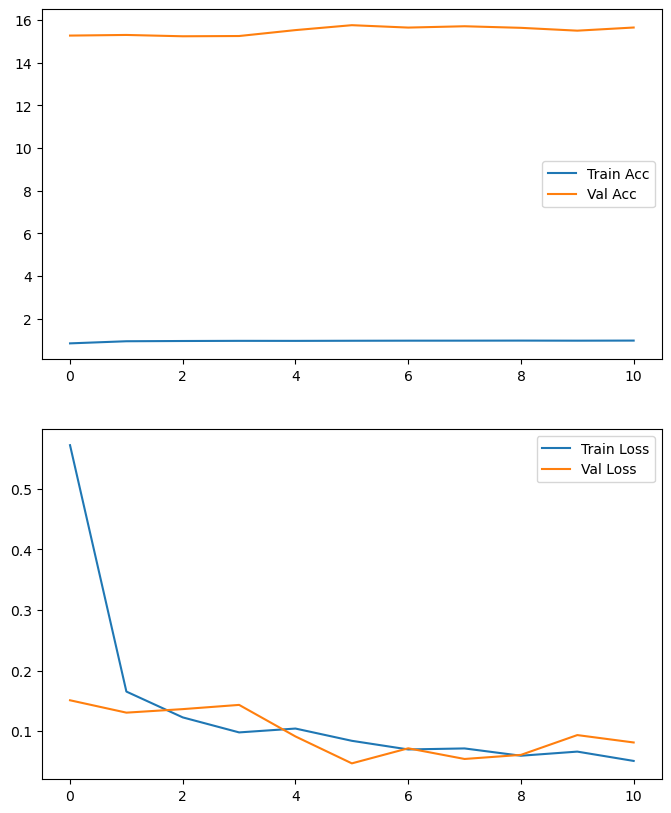

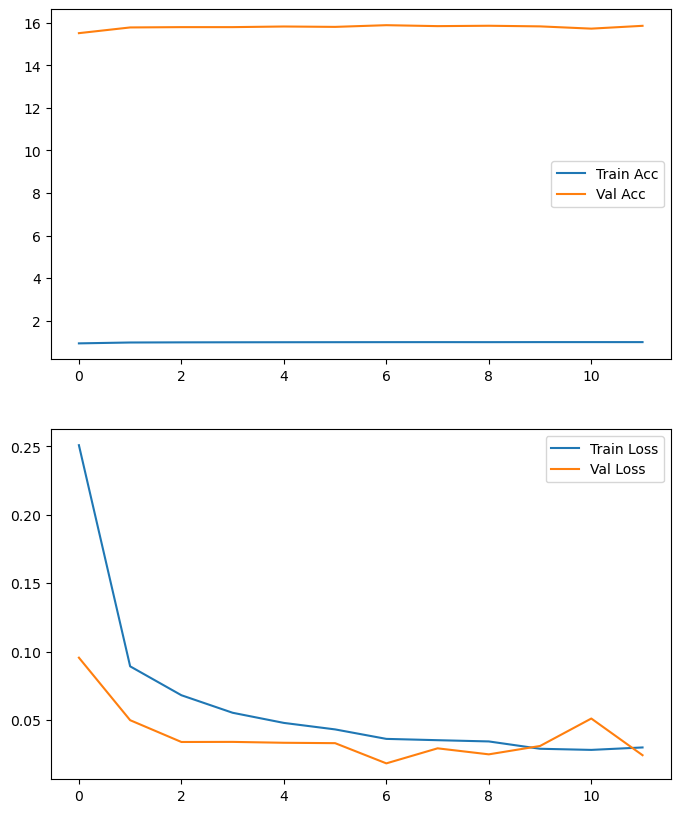

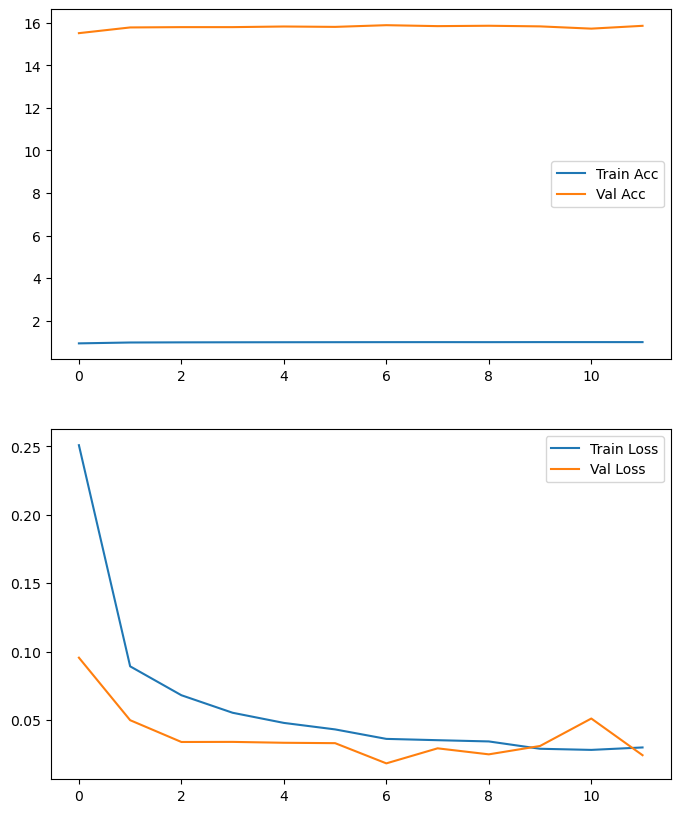

In [13]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(fr"input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(fr"input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(fr"input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/resnet/{s}/resnet50_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/resnet50_{s}.png")


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\kubac/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100.0%
C:\Users\kubac\AppData\Local\Temp\ipykernel_10392\1801917615.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Rospoczyznam szkolenie modelu dla s = 25


C:\Users\kubac\AppData\Local\Temp\ipykernel_10392\1801917615.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 : train_loss = 0.5545, val_loss = 0.1180
Epoch 2 : train_loss = 0.1722, val_loss = 0.1153
Epoch 3 : train_loss = 0.1242, val_loss = 0.0817
Epoch 4 : train_loss = 0.1173, val_loss = 0.0918
Epoch 5 : train_loss = 0.0894, val_loss = 0.1203
Epoch 6 : train_loss = 0.0857, val_loss = 0.0527
Epoch 7 : train_loss = 0.0755, val_loss = 0.0514
Epoch 8 : train_loss = 0.0755, val_loss = 0.1105
Epoch 9 : train_loss = 0.0734, val_loss = 0.0700
Epoch 10 : train_loss = 0.0664, val_loss = 0.0483
Epoch 11 : train_loss = 0.0546, val_loss = 0.1101
Epoch 12 : train_loss = 0.0653, val_loss = 0.0582
Epoch 13 : train_loss = 0.0420, val_loss = 0.0894
Epoch 14 : train_loss = 0.0538, val_loss = 0.0699
Epoch 15 : train_loss = 0.0613, val_loss = 0.1011
Early Stopping at 15
Rospoczyznam szkolenie modelu dla s = 50
Epoch 1 : train_loss = 0.2474, val_loss = 0.1141
Epoch 2 : train_loss = 0.0926, val_loss = 0.0567
Epoch 3 : train_loss = 0.0700, val_loss = 0.0378
Epoch 4 : train_loss = 0.0553, val_loss = 0.0419
E

KeyboardInterrupt: 

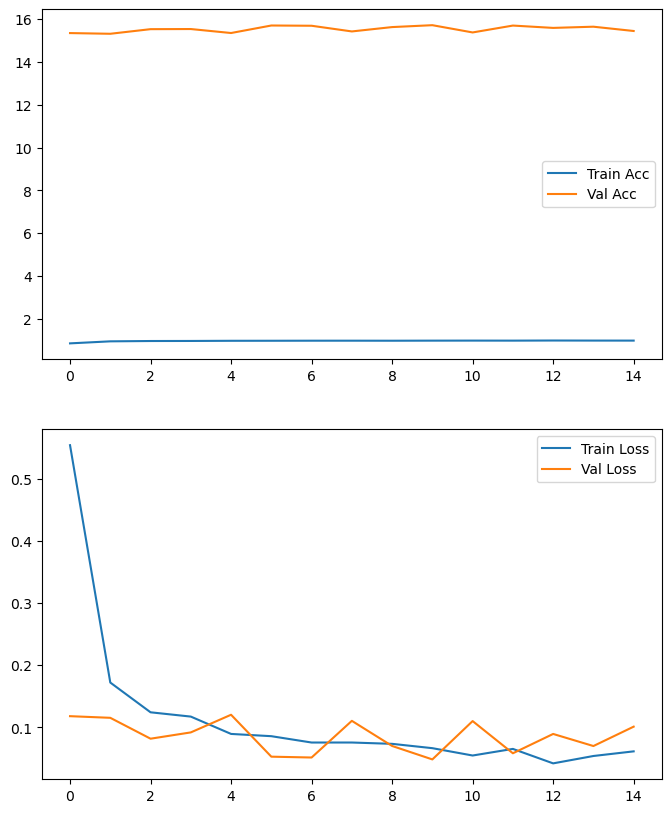

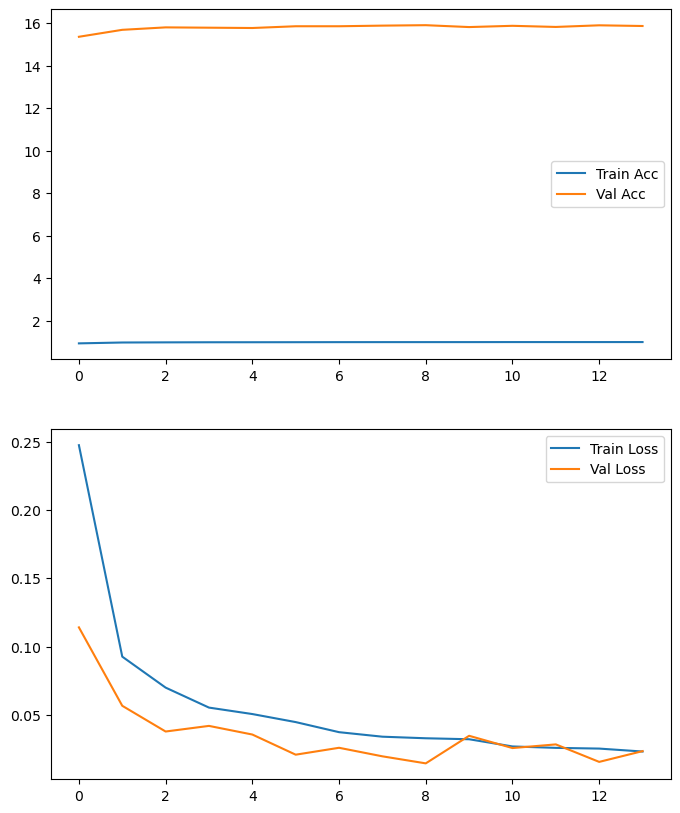

In [14]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/resnet/{s}/resnet101_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/resnet101_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rozpoczynam szkolenie modelu MobileNetV2 dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/mobilenet/{s}/mobilenetv2_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/remobilenetv2_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/mobilenet/{s}/mobilenetv3_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/mobilenetv3_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/efficientnet/{s}/efficientnetb0_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/efficientnetb0_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((240,240)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/efficientnet/{s}/efficientnetb1_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/efficientnetb1_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]            
        )
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]            
        )
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/vit/{s}/vit_b_16_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/vit_b_16__{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]            
        )
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]            
        )
    ])

    train_ds = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1)

    model.heads.head = nn.Linear(model.heads.head.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_ds)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/vit/{s}/vit_b_32_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/vit_b_32__{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(model.classifier.in_features,38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_ds)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), fr"output/DenseNet121_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(fr"output/DenseNet121_{s}.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"nowe/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(model.classifier.in_features,38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_ds)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), fr"output/DenseNet169_{s}.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(fr"output/DenseNet169_{s}.png")


In [ ]:
sets = [75,50,25]

In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"nowe/noise/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(model.classifier.in_features,38)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_ds)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), fr"output/densenet121_{s}_noise.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(fr"output/densenet121_{s}_noise.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(f"nowe/noise/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(f"nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(f"nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, num_workers=4, pin_memory=True, prefetch_factor = 2,  persistent_workers=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(model.classifier.in_features,38)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_ds)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), fr"output/densenet169_{s}_noise.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(fr"output/densenet169_{s}_noise.png")


In [ ]:
for s in sets:
    set_seed(30)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(contrast=0.2),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ToTensor(),
    ])

    test_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(fr"input_data/new_datasets/nowe/noise/{s}/train", transform=train_transform)
    val_ds   = datasets.ImageFolder(fr"input_data/new_datasets/nowe/100/val", transform=test_val_transform)
    test_ds  = datasets.ImageFolder(fr"input_data/new_datasets/nowe/100/test", transform=test_val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH)
    test_loader  = DataLoader(test_ds, batch_size=BATCH)

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, 38)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()
    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    train_acc_hist,val_acc_hist = [],[]
    train_loss_hist,val_loss_hist = [],[]
    print(f"Rospoczyznam szkolenie modelu dla s = {s}")
    for epochs in range(EPOCHS):
        model.train()
        running_loss,correct = 0.0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs,labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss/len(train_loader)
        train_acc = correct/len(train_ds)
        
        model.eval()
        val_loss, correct = 0.0,0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs,labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss = val_loss/len(val_loader)
        val_acc = correct/len(val_loader)

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"Epoch {epochs+1} : train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/resnet/{s}/resnet50_{s}_noise.pth")
        else:
            patience_counter+=1
            if(patience_counter==patience):
                print(f"Early Stopping at {epochs+1}")
                break

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    axes[0].plot(train_acc_hist, label="Train Acc")
    axes[0].plot(val_acc_hist, label="Val Acc")
    axes[0].legend()

    axes[1].plot(train_loss_hist, label="Train Loss")
    axes[1].plot(val_loss_hist, label="Val Loss")
    axes[1].legend()

    plt.savefig(f"D:/praca_dyplomowa_magisterska_repo/praca_dyplomowa_magisterskie/output/plots/resnet50_{s}_noise.png")
